# Week 4 - Qwen Ablation Study
This notebook fine-tunes only Qwen and runs ablations on:
- learning rate
- LoRA rank (r=4 vs r=8)
- max sequence length (512 vs 768)


In [12]:
# Cell 1 - Setup and imports
%pip install -q -U transformers accelerate peft bitsandbytes trl evaluate pandas numpy matplotlib seaborn tabulate

import os
import re
import gc
import json
import random
import warnings
from collections import Counter
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    set_seed,
)
from peft import LoraConfig, get_peft_model, PeftModel

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Note: you may need to restart the kernel to use updated packages.
DEVICE: cuda
GPU: NVIDIA GeForce RTX 5070



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# Cell 2 - Load and split data
from pathlib import Path

CANDIDATE_PATHS = [
    Path("/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/balanced_1000.csv"),
    Path("/kaggle/input/bangladesh-legal-acts-dataset/balanced_1000.csv"),
    Path("balanced_1000.csv"),
    Path("./data/balanced_1000.csv"),
]

DATA_PATH = None
for p in CANDIDATE_PATHS:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    matches = list(Path(".").rglob("balanced_1000.csv"))
    if matches:
        DATA_PATH = matches[0]

if DATA_PATH is None:
    try:
        import kagglehub
        ds_root = Path(kagglehub.dataset_download("sakhadib/bangladesh-legal-acts-dataset"))
        matches = list(ds_root.rglob("balanced_1000.csv"))
        if matches:
            DATA_PATH = matches[0]
    except Exception as e:
        print("kagglehub download failed:", e)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find balanced_1000.csv. Put it in the working folder or ./data/, "
        "or enable internet for kagglehub auto-download."
    )

df = pd.read_csv(DATA_PATH)
print(f"Using dataset: {DATA_PATH}")

df_shuffled = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
n_total = len(df_shuffled)
n_train = int(0.8 * n_total)
n_temp = n_total - n_train
n_valid = n_temp // 2

train_df_raw = df_shuffled.iloc[:n_train].copy()
valid_df_raw = df_shuffled.iloc[n_train:n_train + n_valid].copy()
test_df_raw  = df_shuffled.iloc[n_train + n_valid:].copy()

print("Raw Train:", train_df_raw.shape)
print("Raw Valid:", valid_df_raw.shape)
print("Raw Test :", test_df_raw.shape)

Using dataset: C:\Users\Admin\.cache\kagglehub\datasets\sakhadib\bangladesh-legal-acts-dataset\versions\5\balanced_1000.csv
Raw Train: (2528, 4)
Raw Valid: (316, 4)
Raw Test : (316, 4)


In [14]:
# Cell 3 - Convert to QA format
def convert_to_qa(df):
    rows = []
    for _, r in df.iterrows():
        act_title    = str(r["act_title"]).strip()    if pd.notna(r["act_title"])    else "this law"
        year         = str(r["year"]).strip()          if pd.notna(r["year"])         else ""
        section_text = str(r["section"]).strip()       if pd.notna(r["section"])      else ""

        if not section_text:
            continue

        act_name = f"{act_title} ({year})" if year else act_title
        question = f"What does {act_name} say in this provision?"
        context  = [{"id": "C1", "text": section_text}]
        answer   = section_text

        rows.append({
            "question":  question,
            "context":   context,
            "answer":    answer,
            "citations": ["C1"],
            "language":  "en",
        })
    return pd.DataFrame(rows)

train_df = convert_to_qa(train_df_raw)
valid_df = convert_to_qa(valid_df_raw)
test_df  = convert_to_qa(test_df_raw)

print("QA Train:", train_df.shape)
print("QA Valid:", valid_df.shape)
print("QA Test :", test_df.shape)
display(train_df.head(2))

QA Train: (2497, 5)
QA Valid: (309, 5)
QA Test : (311, 5)


,question,context,answer,citations,language
0,What does [বাংলাদেশ মেরিটাইম ইউনিভার্সিটি] আইন...,"[{'id': 'C1', 'text': '৫৯। বিশ্ববিদ্যালয়ের বা...",৫৯। বিশ্ববিদ্যালয়ের বার্ষিক প্রতিবেদন সিন্ডিক...,[C1],en
1,"What does The Finance Act, 1974 (1974) say in ...","[{'id': 'C1', 'text': '5. In the Amusement Tax...","5. In the Amusement Tax Act, 1922 (Ben. Act V ...",[C1],en


In [15]:
# Cell 4 - Prompt and formatting helpers
SYSTEM_PROMPT = """You are a legal QA assistant.
Answer ONLY from the provided context.
Rules:
1. Do not invent facts.
2. If the answer is not fully supported by the context, say: "Insufficient evidence in provided context."
3. Cite supporting context IDs inline like [C1], [C2].
4. Match the language of the user's question.
"""

def normalize_context(ctx):
    out = []
    if isinstance(ctx, list):
        for i, item in enumerate(ctx, start=1):
            if isinstance(item, dict):
                out.append({"id": item.get("id", f"C{i}"), "text": item.get("text", "")})
            else:
                out.append({"id": f"C{i}", "text": str(item)})
    return out

def build_context_block(ctx_items):
    ctx_items = normalize_context(ctx_items)
    return "\n\n".join([f"[{x['id']}] {x['text']}" for x in ctx_items])

def build_user_prompt(example):
    context_block = build_context_block(example["context"])
    return f"""Question:
{example['question']}

Context:
{context_block}

Provide a grounded answer with inline citations.
"""

def safe_citations(citations):
    if isinstance(citations, list):
        return [str(x) for x in citations]
    if isinstance(citations, str):
        cleaned = citations.strip().strip("[]")
        if not cleaned:
            return []
        return [x.strip().strip("'").strip('\"') for x in cleaned.split(",")]
    return []

def append_inline_citations(answer, citations):
    cits = safe_citations(citations)
    if not cits:
        return str(answer).strip()
    inline = " ".join([f"[{c}]" for c in cits])
    ans = str(answer).strip()
    if inline in ans:
        return ans
    return f"{ans} {inline}"

def build_messages(example):
    assistant_text = append_inline_citations(example["answer"], example.get("citations", []))
    return [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": build_user_prompt(example)},
        {"role": "assistant", "content": assistant_text},
    ]

In [16]:
# Cell 5 - SFT formatting and dataset class
def dataframe_to_sft_df(df, tokenizer):
    rows = []
    for _, row in df.iterrows():
        ex = row.to_dict()
        messages = build_messages(ex)
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        rows.append({"text": text})
    return pd.DataFrame(rows)

class TextSFTDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_length=1024):
        self.texts     = df["text"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc  = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = item["input_ids"].clone()
        item["labels"][item["attention_mask"] == 0] = -100
        return item

In [ ]:
# Cell 6 - Evaluation helpers 
CITATION_RE = re.compile(r"\[(C\d+)\]")
BN_RE       = re.compile(r"[\u0980-\u09FF]")

def extract_pred_citations(text):
    return sorted(set(CITATION_RE.findall(text or "")))

def normalize_context_map(ctx):
    items = normalize_context(ctx)
    return {x["id"]: x["text"] for x in items}

def split_sentences(text):
    if not text:
        return []
    return [s.strip() for s in re.split(r"(?<=[.!?।])\s+", text) if s.strip()]

def token_list(text):
    """Return a list of tokens (preserves duplicates for Counter-based scoring)."""
    text = (text or "").lower()
    text = re.sub(r"[^\w\u0980-\u09FF\s]", " ", text)
    return text.split()

def token_set(text):
    return set(token_list(text))

def sentence_support_score(sentence, context_text):
    s_tokens = token_set(sentence)
    c_tokens = token_set(context_text)
    if not s_tokens:
        return 0.0
    return len(s_tokens & c_tokens) / len(s_tokens)

def safe_citation_list(citations):
    if isinstance(citations, list):
        return [str(x).strip().strip("'").strip('\"') for x in citations]
    if isinstance(citations, str):
        cleaned = citations.strip().strip("[]")
        if not cleaned:
            return []
        return [x.strip().strip("'").strip('\"') for x in cleaned.split(",")]
    return []

def evaluate_prediction_row(row, support_threshold=0.45):
    gold_cits = set(safe_citation_list(row["gold_citations"]))
    pred_cits = set(extract_pred_citations(row["prediction"]))

    ctx_map           = normalize_context_map(row["context"])
    valid_context_ids = set(ctx_map.keys())
    hallucinated_cits = pred_cits - valid_context_ids

   
    cit_precision = len(pred_cits & gold_cits) / max(len(pred_cits), 1)
    cit_recall    = len(pred_cits & gold_cits) / max(len(gold_cits), 1)
    cit_f1        = (
        0.0 if (cit_precision + cit_recall) == 0
        else 2 * cit_precision * cit_recall / (cit_precision + cit_recall)
    )

    hallucinated_citation_rate = len(hallucinated_cits) / max(len(pred_cits), 1)

    full_context       = " ".join(ctx_map.values())
    sents              = split_sentences(row["prediction"])
    supported          = 0
    factual_sent_count = 0
    for s in sents:
        if len(s.split()) < 4:
            continue
        factual_sent_count += 1
        if sentence_support_score(s, full_context) >= support_threshold:
            supported += 1

    unsupported_sentence_rate = (
        1 - (supported / factual_sent_count) if factual_sent_count > 0 else 0.0
    )
    abstention = int("Insufficient evidence in provided context" in (row["prediction"] or ""))

    return pd.Series({
        "citation_precision":        cit_precision,
        "citation_recall":           cit_recall,
        "citation_f1":               cit_f1,
        "hallucinated_citation_rate": hallucinated_citation_rate,
        "unsupported_sentence_rate": unsupported_sentence_rate,
        "abstention_rate":           abstention,
    })

def detect_language_heuristic(text):
    text     = text or ""
    bn_chars = len(BN_RE.findall(text))
    en_chars = len(re.findall(r"[A-Za-z]", text))
    if bn_chars > 0 and en_chars > 0:
        return "mixed"
    elif bn_chars > 0:
        return "bn"
    elif en_chars > 0:
        return "en"
    return "unknown"

def language_consistency_row(row):
    q_lang    = row.get("language", "unknown")
    pred_lang = detect_language_heuristic(row["prediction"])
    if q_lang == "mixed":
        ok = pred_lang in {"mixed", "bn", "en"}
    elif q_lang == "bn":
        ok = pred_lang in {"bn", "mixed"}
    elif q_lang == "en":
        ok = pred_lang in {"en", "mixed"}
    else:
        ok = False
    return pd.Series({"language_consistent": int(ok)})

def rouge_like_f1(pred, gold):
    """Proper ROUGE-1 F1 using Counter (multiset) overlap, not set overlap.
    FIX: original used token_set() which deduplicates and over-inflates scores
    on repetitive legal text."""
    pred_toks = Counter(token_list(pred))
    gold_toks = Counter(token_list(gold))
    if not pred_toks or not gold_toks:
        return 0.0
    overlap = sum((pred_toks & gold_toks).values())
    p = overlap / max(sum(pred_toks.values()), 1)
    r = overlap / max(sum(gold_toks.values()), 1)
    return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

In [ ]:
# Cell 7 - Qwen setup and experiment functions 
QWEN_BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_DIR      = Path("/kaggle/working/llm_outputs_ablation_qwen")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

def load_qwen_tokenizer():
    tok = AutoTokenizer.from_pretrained(QWEN_BASE_MODEL, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    return tok

def build_qwen_lora_model(lora_r):
    model = AutoModelForCausalLM.from_pretrained(
        QWEN_BASE_MODEL,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    model.config.use_cache = False  # correct: disable during training only

    qwen_lora = LoraConfig(
        r=lora_r,
        lora_alpha=2 * lora_r,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    )
    model = get_peft_model(model, qwen_lora)
    return model

def load_qwen_peft_inference_model(adapter_dir):
    tokenizer = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        QWEN_BASE_MODEL,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    model = PeftModel.from_pretrained(model, adapter_dir)
    model.eval()
    return tokenizer, model

def generate_answer(tokenizer, model, example, max_new_tokens=220):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": build_user_prompt(example)},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
    ).to(model.device)

    prompt_len = inputs["input_ids"].shape[1]  

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,      # ignored when do_sample=False; set to 1.0 to avoid warnings
            # FIX 2: use_cache=False removed — was causing O(n²) slowdown during inference
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    
    new_tokens = output[0][prompt_len:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def run_model_on_test(tokenizer, model, test_df, max_examples=100):
    rows = []
    n    = min(max_examples, len(test_df))

    for i in range(n):
        ex   = test_df.iloc[i].to_dict()
        pred = generate_answer(tokenizer, model, ex)

        rows.append({
            "idx":            i,
            "question":       ex["question"],
            "language":       ex.get("language", "unknown"),
            "gold_answer":    ex["answer"],
            "gold_citations": ex.get("citations", []),
            "context":        ex["context"],
            "prediction":     pred,
        })

        if (i + 1) % 20 == 0:
            print(f"  completed {i+1}/{n}")

    return pd.DataFrame(rows)

In [ ]:
# Cell 8 - Single experiment runner 
def run_experiment(cfg, shared_tokenizer):
    """
    Run one ablation configuration.
    shared_tokenizer is passed in so the tokenizer is not reloaded on every run.
    """
    run_id  = f"lr{cfg['learning_rate']}_r{cfg['lora_r']}_len{cfg['max_length']}"
    run_dir = OUTPUT_DIR / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    
    summary_path = run_dir / "summary_metrics.csv"
    if summary_path.exists():
        print(f"  [skip] {run_id} already done — loading cached result")
        return pd.read_csv(summary_path).iloc[0].to_dict()

    print(f"\n=== Running {run_id} ===")
    gc.collect()
    torch.cuda.empty_cache()
    set_seed(cfg["seed"])

    qwen_train_sft = dataframe_to_sft_df(train_df, shared_tokenizer)
    qwen_valid_sft = dataframe_to_sft_df(valid_df, shared_tokenizer)

    qwen_train_ds = TextSFTDataset(qwen_train_sft, shared_tokenizer, max_length=cfg["max_length"])
    qwen_valid_ds = TextSFTDataset(qwen_valid_sft, shared_tokenizer, max_length=cfg["max_length"])

    qwen_model = build_qwen_lora_model(cfg["lora_r"])

    qwen_args = TrainingArguments(
        output_dir=str(run_dir),
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=8,
        learning_rate=cfg["learning_rate"],
        num_train_epochs=1,
        logging_steps=20,
        eval_strategy="steps",
        eval_steps=100,
        save_steps=100,
        save_total_limit=2,
        bf16=torch.cuda.is_available(),
        fp16=not torch.cuda.is_available(),
        warmup_ratio=0.05,
        lr_scheduler_type="cosine",
        report_to="none",
        remove_unused_columns=False,
    )

    qwen_trainer = Trainer(
        model=qwen_model,
        args=qwen_args,
        train_dataset=qwen_train_ds,
        eval_dataset=qwen_valid_ds,
    )

    train_output = qwen_trainer.train()

    qwen_adapter_path = run_dir / "adapter"
    qwen_trainer.model.save_pretrained(str(qwen_adapter_path))
    shared_tokenizer.save_pretrained(str(qwen_adapter_path))

    qwen_eval_tokenizer, qwen_eval_model = load_qwen_peft_inference_model(str(qwen_adapter_path))
    pred_df = run_model_on_test(qwen_eval_tokenizer, qwen_eval_model, test_df, max_examples=cfg["max_eval_examples"])

    metrics_df = pred_df.copy()
    metrics_df = pd.concat([metrics_df, metrics_df.apply(evaluate_prediction_row, axis=1)], axis=1)
    metrics_df["answer_overlap_f1"] = metrics_df.apply(
        lambda r: rouge_like_f1(r["prediction"], r["gold_answer"]), axis=1
    )
    metrics_df = pd.concat([metrics_df, metrics_df.apply(language_consistency_row, axis=1)], axis=1)

    result = {
        "run_id":                     run_id,
        "learning_rate":              cfg["learning_rate"],
        "lora_r":                     cfg["lora_r"],
        "max_length":                 cfg["max_length"],
        "seed":                       cfg["seed"],
        "train_runtime_sec":          float(train_output.metrics.get("train_runtime", np.nan)),
        "train_loss":                 float(train_output.metrics.get("train_loss", np.nan)),
        "citation_precision":         metrics_df["citation_precision"].mean(),
        "citation_recall":            metrics_df["citation_recall"].mean(),
        "citation_f1":                metrics_df["citation_f1"].mean(),
        "hallucinated_citation_rate": metrics_df["hallucinated_citation_rate"].mean(),
        "unsupported_sentence_rate":  metrics_df["unsupported_sentence_rate"].mean(),
        "abstention_rate":            metrics_df["abstention_rate"].mean(),
        "language_consistency_rate":  metrics_df["language_consistent"].mean(),
        "answer_overlap_f1":          metrics_df["answer_overlap_f1"].mean(),
        "adapter_path":               str(qwen_adapter_path),
    }

    metrics_df.to_csv(run_dir / "detail_metrics.csv", index=False)
    pd.DataFrame([result]).to_csv(summary_path, index=False)

    del qwen_trainer, qwen_model, qwen_eval_model
    gc.collect()
    torch.cuda.empty_cache()

    return result

In [ ]:
# Cell 9 - Ablation grid and run
shared_tokenizer = load_qwen_tokenizer()
print("Tokenizer loaded once:", type(shared_tokenizer).__name__)

LR_LIST     = [1e-4, 2e-4, 3e-4]
R_LIST      = [4, 8]
MAXLEN_LIST = [512, 768]

BASE_CFG = {
    "seed":             42,
    "max_eval_examples": 100,
}

configs = []
for lr, r, max_len in product(LR_LIST, R_LIST, MAXLEN_LIST):
    cfg = dict(BASE_CFG)
    cfg["learning_rate"] = lr
    cfg["lora_r"]        = r
    cfg["max_length"]    = max_len
    configs.append(cfg)

print("Total ablation runs:", len(configs))

all_results = []
for cfg in configs:
    all_results.append(run_experiment(cfg, shared_tokenizer))

ablation_df  = pd.DataFrame(all_results)
ablation_csv = OUTPUT_DIR / "qwen_ablation_results.csv"
ablation_df.to_csv(ablation_csv, index=False)

print("Saved ablation results to:", ablation_csv)
display(ablation_df)

Tokenizer loaded once: Qwen2Tokenizer
Total ablation runs: 12
  [skip] lr0.0001_r4_len512 already done — loading cached result
  [skip] lr0.0001_r4_len768 already done — loading cached result

=== Running lr0.0001_r8_len512 ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
100,0.809413,0.760528
200,0.798691,0.690155
300,0.708446,0.682930


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
100,0.666585,0.617213
200,0.702804,0.592345
300,0.637077,0.585647


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  completed 20/100
  completed 40/100
  completed 60/100
  completed 80/100
  completed 100/100
Saved ablation results to: \kaggle\working\llm_outputs_ablation_qwen\qwen_ablation_results.csv


,run_id,learning_rate,lora_r,max_length,seed,train_runtime_sec,train_loss,citation_precision,citation_recall,citation_f1,hallucinated_citation_rate,unsupported_sentence_rate,abstention_rate,language_consistency_rate,answer_overlap_f1,adapter_path
0,lr0.0001_r4_len512,0.0001,4,512,42,625.2697,0.966911,0.57,0.57,0.57,0.00,0.030,0.0,0.78,0.797349,\kaggle\working\llm_outputs_ablation_qwen\lr0....
1,lr0.0001_r4_len768,0.0001,4,768,42,701.7832,0.890518,0.57,0.57,0.57,0.00,0.035,0.0,0.81,0.796961,\kaggle\working\llm_outputs_ablation_qwen\lr0....
2,lr0.0001_r8_len512,0.0001,8,512,42,577.0336,0.907749,0.57,0.57,0.57,0.00,0.030,0.0,0.79,0.802805,\kaggle\working\llm_outputs_ablation_qwen\lr0....
3,lr0.0001_r8_len768,0.0001,8,768,42,693.0372,0.839499,0.57,0.57,0.57,0.00,0.030,0.0,0.79,0.802541,\kaggle\working\llm_outputs_ablation_qwen\lr0....
4,lr0.0002_r4_len512,0.0002,4,512,42,561.0927,0.873620,0.57,0.57,0.57,0.00,0.045,0.0,0.80,0.799234,\kaggle\working\llm_outputs_ablation_qwen\lr0....
5,lr0.0002_r4_len768,0.0002,4,768,42,693.5035,0.810154,0.57,0.57,0.57,0.00,0.035,0.0,0.80,0.799548,\kaggle\working\llm_outputs_ablation_qwen\lr0....
6,lr0.0002_r8_len512,0.0002,8,512,42,558.7722,0.835075,0.57,0.57,0.57,0.00,0.030,0.0,0.79,0.798559,\kaggle\working\llm_outputs_ablation_qwen\lr0....
7,lr0.0002_r8_len768,0.0002,8,768,42,691.8669,0.776068,0.57,0.57,0.57,0.01,0.030,0.0,0.79,0.801364,\kaggle\working\llm_outputs_ablation_qwen\lr0....
8,lr0.0003_r4_len512,0.0003,4,512,42,561.4973,0.835352,0.57,0.57,0.57,0.00,0.030,0.0,0.79,0.797992,\kaggle\working\llm_outputs_ablation_qwen\lr0....
9,lr0.0003_r4_len768,0.0003,4,768,42,692.5808,0.776337,0.57,0.57,0.57,0.00,0.040,0.0,0.79,0.799648,\kaggle\working\llm_outputs_ablation_qwen\lr0....


In [ ]:
# Cell 10 - Ablation summary 
from tabulate import tabulate

rank_cols_high = [
    "citation_precision",
    "citation_recall",
    "citation_f1",
    "language_consistency_rate",
    "answer_overlap_f1",
    "abstention_rate",        
]

rank_cols_low = [
    "hallucinated_citation_rate",
    "unsupported_sentence_rate",
    
]

summary_df = ablation_df.copy()

for col in rank_cols_high:
    summary_df[f"rank_{col}"] = summary_df[col].rank(ascending=False, method="dense")

for col in rank_cols_low:
    summary_df[f"rank_{col}"] = summary_df[col].rank(ascending=True, method="dense")

summary_df = summary_df.sort_values(
    by=["citation_f1", "language_consistency_rate", "hallucinated_citation_rate", "answer_overlap_f1"],
    ascending=[False, False, True, False],
).reset_index(drop=True)

best = summary_df.iloc[0]

print("Wednesday Update: Best configuration identified\n")

table_data = [
    ["Run ID",                   best["run_id"]],
    ["Learning Rate",            best["learning_rate"]],
    ["LoRA Rank (r)",            int(best["lora_r"])],
    ["Max Sequence Length",      int(best["max_length"])],
    ["Citation Precision",       f"{best['citation_precision']:.4f}"],
    ["Citation Recall",          f"{best['citation_recall']:.4f}"],
    ["Citation F1",              f"{best['citation_f1']:.4f}"],
    ["Language Consistency Rate", f"{best['language_consistency_rate']:.4f}"],
    ["Hallucinated Citation Rate", f"{best['hallucinated_citation_rate']:.4f}"],
    ["Answer Overlap F1",        f"{best['answer_overlap_f1']:.4f}"],
    ["Abstention Rate",          f"{best['abstention_rate']:.4f}"],
]

print(tabulate(table_data, headers=["Metric", "Best Configuration Value"], tablefmt="grid"))

summary_path = OUTPUT_DIR / "qwen_ablation_ranked_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\nSaved ranked summary to: {summary_path}")
display(summary_df)

Wednesday Update: Best configuration identified

+----------------------------+----------------------------+
| Metric                     | Best Configuration Value   |
+============================+============================+
| Run ID                     | lr0.0001_r4_len768         |
+----------------------------+----------------------------+
| Learning Rate              | 0.0001                     |
+----------------------------+----------------------------+
| LoRA Rank (r)              | 4                          |
+----------------------------+----------------------------+
| Max Sequence Length        | 768                        |
+----------------------------+----------------------------+
| Citation Precision         | 0.5700                     |
+----------------------------+----------------------------+
| Citation Recall            | 0.5700                     |
+----------------------------+----------------------------+
| Citation F1                | 0.5700              

,run_id,learning_rate,lora_r,max_length,seed,train_runtime_sec,train_loss,citation_precision,citation_recall,citation_f1,...,answer_overlap_f1,adapter_path,rank_citation_precision,rank_citation_recall,rank_citation_f1,rank_language_consistency_rate,rank_answer_overlap_f1,rank_abstention_rate,rank_hallucinated_citation_rate,rank_unsupported_sentence_rate
0,lr0.0001_r4_len768,0.0001,4,768,42,701.7832,0.890518,0.57,0.57,0.57,...,0.796961,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,1.0,12.0,1.0,1.0,3.0
1,lr0.0002_r4_len768,0.0002,4,768,42,693.5035,0.810154,0.57,0.57,0.57,...,0.799548,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,2.0,6.0,1.0,1.0,3.0
2,lr0.0002_r4_len512,0.0002,4,512,42,561.0927,0.873620,0.57,0.57,0.57,...,0.799234,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,2.0,7.0,1.0,1.0,5.0
3,lr0.0001_r8_len512,0.0001,8,512,42,577.0336,0.907749,0.57,0.57,0.57,...,0.802805,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,3.0,1.0,1.0,1.0,2.0
4,lr0.0001_r8_len768,0.0001,8,768,42,693.0372,0.839499,0.57,0.57,0.57,...,0.802541,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,3.0,2.0,1.0,1.0,2.0
5,lr0.0003_r4_len768,0.0003,4,768,42,692.5808,0.776337,0.57,0.57,0.57,...,0.799648,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,3.0,5.0,1.0,1.0,4.0
6,lr0.0002_r8_len512,0.0002,8,512,42,558.7722,0.835075,0.57,0.57,0.57,...,0.798559,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,3.0,8.0,1.0,1.0,2.0
7,lr0.0003_r4_len512,0.0003,4,512,42,561.4973,0.835352,0.57,0.57,0.57,...,0.797992,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,3.0,10.0,1.0,1.0,2.0
8,lr0.0002_r8_len768,0.0002,8,768,42,691.8669,0.776068,0.57,0.57,0.57,...,0.801364,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,3.0,3.0,1.0,2.0,2.0
9,lr0.0003_r8_len768,0.0003,8,768,42,692.5231,0.748956,0.57,0.57,0.57,...,0.801126,\kaggle\working\llm_outputs_ablation_qwen\lr0....,1.0,1.0,1.0,4.0,4.0,1.0,1.0,1.0


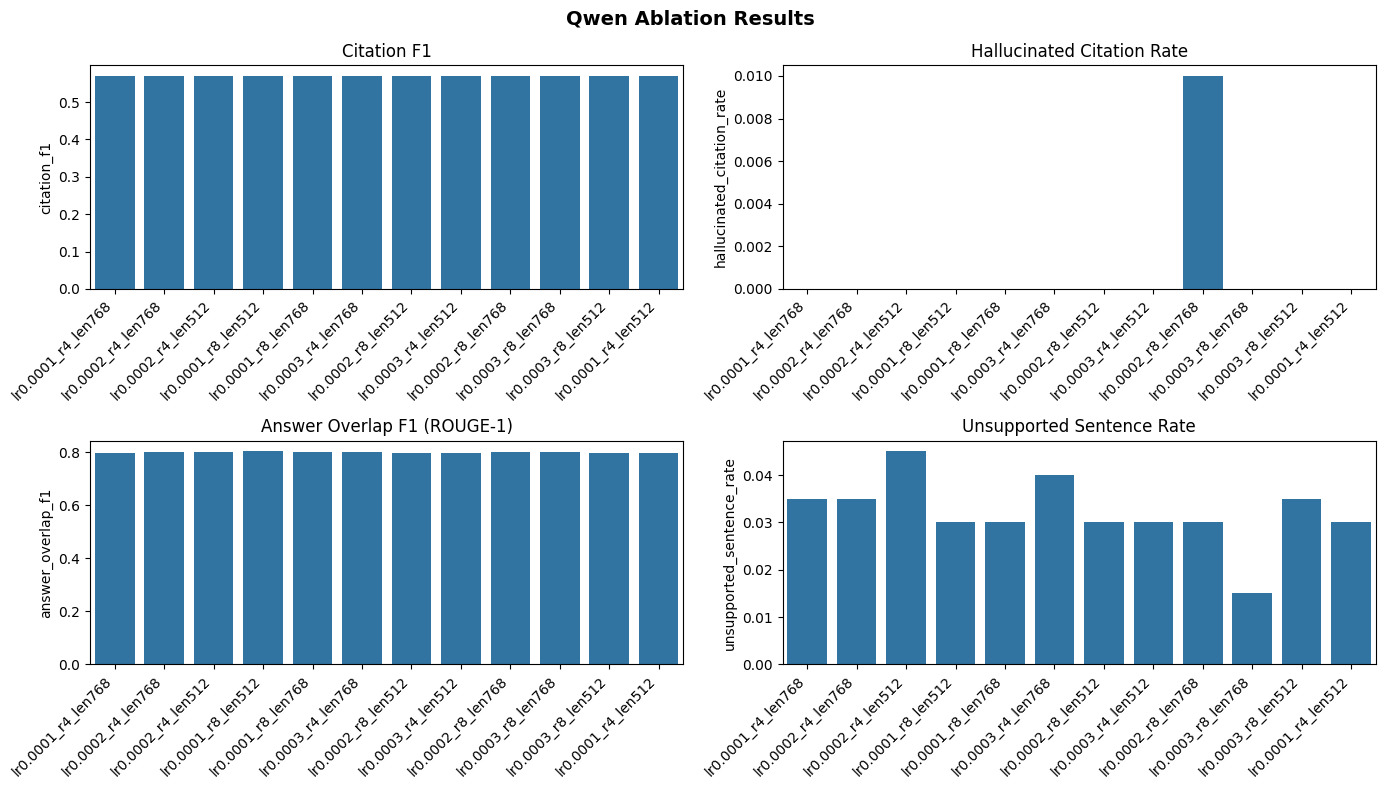

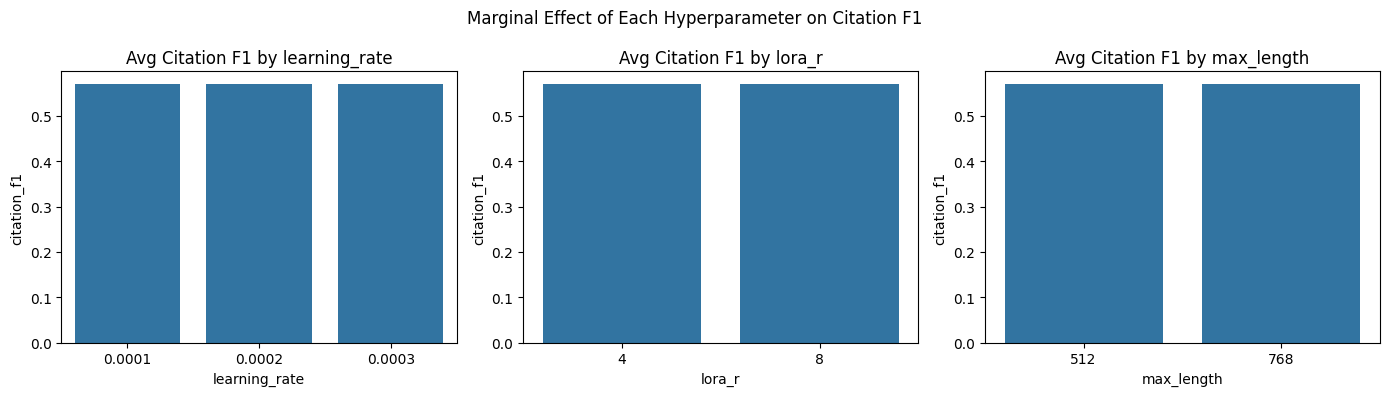

Plots saved to \kaggle\working\llm_outputs_ablation_qwen


In [23]:
# Cell 11 - Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics_to_plot = [
    ("citation_f1",               "Citation F1",               False),
    ("hallucinated_citation_rate","Hallucinated Citation Rate", False),
    ("answer_overlap_f1",         "Answer Overlap F1 (ROUGE-1)",False),
    ("unsupported_sentence_rate", "Unsupported Sentence Rate",  False),
]

for ax, (col, title, _) in zip(axes.flatten(), metrics_to_plot):
    sns.barplot(data=summary_df, x="run_id", y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

plt.suptitle("Qwen Ablation Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-variable marginal effect plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, ["learning_rate", "lora_r", "max_length"]):
    grouped = summary_df.groupby(var)["citation_f1"].mean().reset_index()
    sns.barplot(data=grouped, x=var, y="citation_f1", ax=ax)
    ax.set_title(f"Avg Citation F1 by {var}")
    ax.set_xlabel(var)

plt.suptitle("Marginal Effect of Each Hyperparameter on Citation F1", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "marginal_effects.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved to", OUTPUT_DIR)